In [28]:
import pandas as pd
#los datos proceden de una biblioteca del curso MOOC de ML de la UGR
gene_exp_inmune=pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk', index_col=0)
clinical_info_inmune=pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s', index_col=0)
X, y = gene_exp_inmune, clinical_info_inmune
X.head() #Me sirve para comprobar que se han cargado los datos correctamente

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,DNASE2B,GAP43,IRX6,SLC24A4,SPATS1,C3,PRODH,FCRLA,NTS,GAL3ST1,ARHGEF4,CDH19,COCH,ATP1A2,CYSLTR2,SOX9,SV2A,CXADR,AK5,PPAP2C,DPT,GNAL,LTB,SYT1,CRYAB,PLIN4,LEPREL1,BMP8B,LHFPL3,SNHG14,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,5.978334,-0.685417,0.348336,-3.277434,1.647866,1.085731,-3.688381,2.812931,-0.358939,-1.056752,-2.070547,0.065399,-1.857471,-0.520282,-1.184987,-3.290730,-4.481478,4.216455,5.911001,1.956922,0.357386,-3.613990,-1.278264,-0.828133,-4.977243,1.450732,-2.021582,3.099287,1.183965,-0.016843,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,0.456215,-0.064800,0.985150,2.413460,-1.088116,2.023447,0.268412,1.394991,-0.315163,-3.090193,-2.450481,-0.241036,-3.472228,-1.963252,-0.701943,-3.199761,-4.706725,-1.400815,-0.086378,-0.687650,1.089111,0.661946,0.466231,-1.334801,1.898672,-0.249295,2.879136,-0.772093,-2.625362,0.254833,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,0.797042,2.418753,0.064720,1.412074,-1.554924,0.090275,1.161554,0.561755,-0.307166,1.071364,-4.131663,0.467507,0.015271,0.087563,-1.795137,1.793318,-1.938956,3.868821,-1.237304,-0.794170,-0.141239,-3.470104,-1.628557,0.939818,-0.503716,-0.822757,0.057630,-2.354863,-1.986022,-0.232018,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,-0.190744,-1.566020,-1.772022,-3.627182,-2.709313,-1.635945,-0.851969,-3.804818,-0.785258,0.911465,-3.722152,1.363985,-2.584625,1.818265,-1.834645,2.312042,-4.170106,-2.945472,-2.038699,-1.265867,-1.105425,-3.479325,-0.590298,-0.050436,0.185158,-1.856426,-2.070007,-3.661939,-0.936294,0.540451,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,1.338364,0.389436,1.479015,4.494518,1.157180,1.160060,-2.288292,0.130102,5.068077,-1.685944,-1.402830,-0.197673,1.906034,2.720529,1.783348,1.109175,-1.977214,3.481193,0.287940,-3.760099,1.044078,-1.233587,3.637506,0.826966,-0.301250,5.708673,-1.601977,-4.286033,1.333658,-0.661663,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


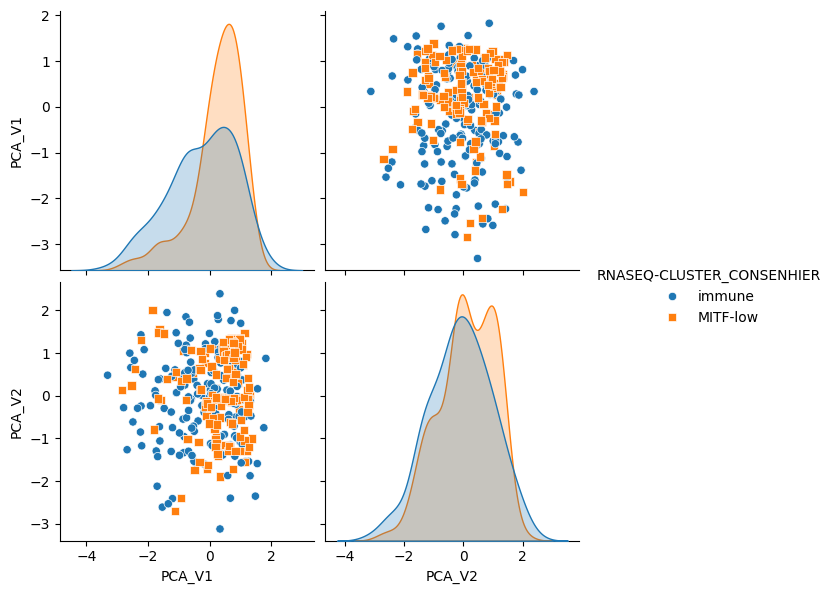

In [29]:
#Transformar el problema en uno de dos dimensiones
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
n_componentes = 2
pca=PCA(n_components=n_componentes)
#Visualizar el problema en dos dimensiones
X_2D=pca.fit_transform(X)
st=StandardScaler()
X_2D=st.fit_transform(X_2D)
df= pd.DataFrame(X_2D, columns=['PCA_V1', 'PCA_V2'])
df=df.join(y)
sns.pairplot(df, hue='RNASEQ-CLUSTER_CONSENHIER', markers=["o", "s"], height=3)
plt.show()


In [30]:
#Validación Hold-out
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
y_int = pd.get_dummies(y).iloc[:,0]
X_2D_train, X_2D_test, y_int_train, y_int_test = train_test_split(X_2D, y_int, random_state=42)
print("Número de instancias en el conjunto de entrenamiento: {}; y test: {}".format(len(X_train), len(X_test)))

Número de instancias en el conjunto de entrenamiento: 252; y test: 84


In [31]:
#Visualizar con sintaxis Scikit-learn
from sklearn import linear_model
lm = linear_model.LinearRegression()
y_train_int=pd.get_dummies(y_train).iloc[:,0]
lm.fit(X_train, y_train_int)
print(lm.intercept_)
print(lm.coef_)

0.3371977981689105
[ 0.00062339 -0.01640629  0.05765623 -0.00365438 -0.03219924  0.02831667
  0.02246995  0.02406873  0.04154468  0.0113776   0.03335884  0.02299525
 -0.00375194  0.04292671  0.01228339 -0.01640771  0.03062444 -0.00302422
 -0.02929467  0.00676286 -0.01947947 -0.02999738  0.02491126 -0.0079843
 -0.00937148  0.00456585  0.00615687 -0.01706812 -0.0042064  -0.03262455
 -0.03213231  0.00450434 -0.05782194 -0.02456257  0.0250594  -0.00637356
  0.04990764 -0.00675726 -0.04263797 -0.07777568  0.03133627  0.01415696
 -0.07683601 -0.08607171 -0.01192452  0.02302473  0.06651956 -0.01050754
  0.04608665 -0.00776793]


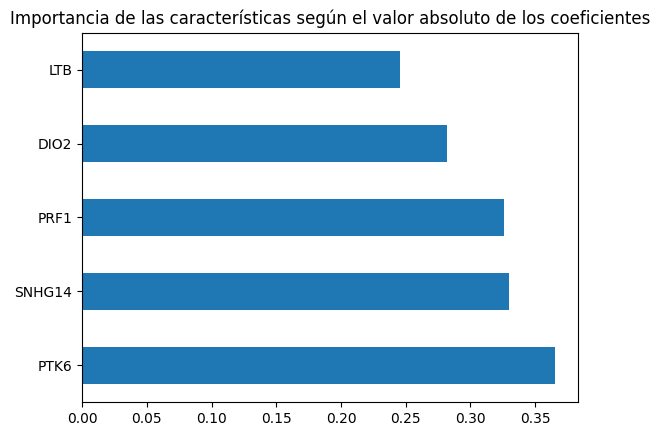

In [32]:
import numpy as np
from sklearn.preprocessing import normalize
importancia = np.abs(lm.coef_)
importancia_norm = normalize(importancia[:,np.newaxis], axis=0).ravel()

#Visualizar la importancia según el valor absoluto de los coeficientes
pd.Series(importancia_norm, index=X_train.columns).nlargest(5).plot(kind='barh')
plt.title('Importancia de las características según el valor absoluto de los coeficientes')
plt.show()

In [33]:
#Consideramos cada clase como valor entero
from sklearn.metrics import accuracy_score
y_test_int = pd.get_dummies(y_test).iloc[:,0]
y_pred = lm.predict(X_test)
y_pred[y_pred >= 0.5] = 1
y_pred[y_pred < 0.5] = 0
print (y_pred[:10])
acc_score = accuracy_score(y_test_int, y_pred)
print("Precisión obtenida: {:.2f}%".format(acc_score*100))

[1. 0. 1. 1. 0. 1. 1. 1. 0. 0.]
Precisión obtenida: 71.43%


In [ ]:
#El modelo KNN es un modelo de clasificación basado en la distancia entre los puntos de datos.
# Para cada punto de datos que queremos clasificar, el modelo KNN busca los k puntos de datos más
# cercanos en el conjunto de entrenamiento y asigna la clase más común entre esos vecinos como la predicción.
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train.squeeze()) 
y_pred = knn.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)
print("Precisión KNN en la partición de test: {:.2f}%".format(acc_score*100))

Precisión KNN en la partición de test: 67.86%


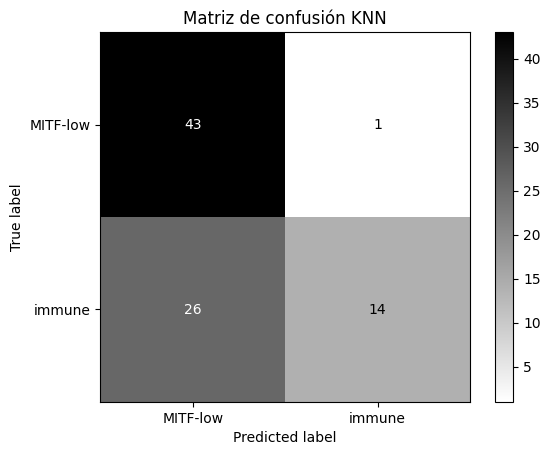

              precision    recall  f1-score   support

    MITF-low       0.62      0.98      0.76        44
      immune       0.93      0.35      0.51        40

    accuracy                           0.68        84
   macro avg       0.78      0.66      0.64        84
weighted avg       0.77      0.68      0.64        84

F1-score para el clasificador KNeighborsClassifier es 0.5091
AUC para el clasificador KNeighborsClassifier es 0.7750


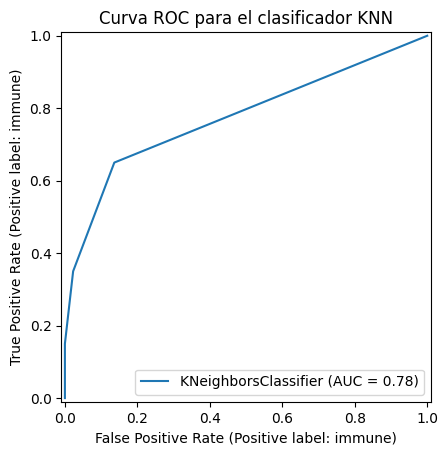

In [48]:
#Repetimos la obtención de métricas de rendimiento pero con el modeleo KNN
from sklearn import metrics
#Matriz de confusión
metrics.ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap='binary')
plt.title('Matriz de confusión KNN')
plt.show()
#Reporte de clasificación y F1-score
print(metrics.classification_report(y_test, y_pred))
f1_score = metrics.f1_score(y_test, y_pred, pos_label='immune')
print("F1-score para el clasificador %s es %.4f"%(knn.__class__.__name__, f1_score))
#Curva ROC y AUC
y_probs = knn.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("AUC para el clasificador %s es %.4f"%(knn.__class__.__name__, auc))
metrics.RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.title('Curva ROC para el clasificador KNN')
plt.show()

<Figure size 1200x900 with 0 Axes>

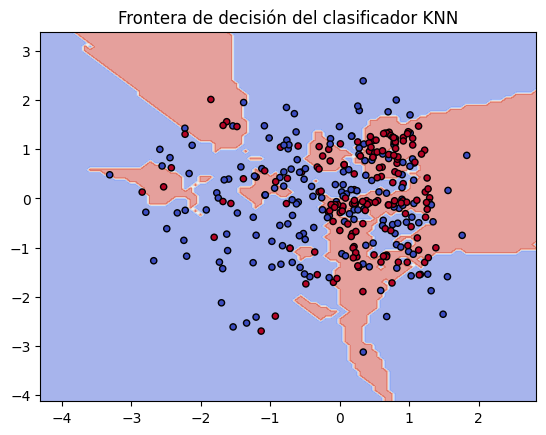

In [49]:
#Crear y entrenar el clasificador con datos 2D y visualizar la frontera de decisión
clf = KNeighborsClassifier()
clf.fit(X_2D_train, y_int_train)
score = clf.score(X_2D_test, y_int_test)
fig = plt.figure (figsize=(12,9))

disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method='predict',
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)
disp.ax_.scatter(X_2D[:,0], X_2D[:,1], c=y_int, edgecolor='k', s=20, cmap=plt.cm.coolwarm)
plt.title("Frontera de decisión del clasificador KNN")
plt.show()